In [1]:
# Enable auto-reload for development
%load_ext autoreload                
%autoreload 2

import pandas as pd
import os
import sys
import os

sys.path.append(os.path.abspath("../../scripts"))

import plots


In [2]:
def load_single_channel(data_folder, channel, cycle_range=None):
    file_path = os.path.join(data_folder, f"{channel}.csv")
    df = pd.read_csv(file_path).dropna()

    if "#NAME?" in df.columns: df = df.rename(columns={"#NAME?": "-Im(Z)/Ohm"})

    df["channel"] = channel  

    if cycle_range is not None:
        lo, hi = cycle_range
        df = df[df['cycle number'].between(lo, hi)].copy()
    else:
        max_cycle = df['cycle number'].max()
        df = df[(df['cycle number'] > 0) & (df['cycle number'] < max_cycle)].copy()

    return df

In [3]:
for folder in ["../../data/03-22-24", "../../data/04-03-24"]:
    print("\n" + "="*80)
    print(f"DATA FOLDER: {folder}")
    print("="*80)
    
    all_channels = sorted([f[:-4] for f in os.listdir(folder) if f.endswith('.csv')])

    for channel in all_channels:
      print(f"\n{'':-^70}")
      print(f"    Channel: {channel}")
      print(f"{'':-^70}")
      
      df = load_single_channel(data_folder=folder, channel=channel)
      
      df_ns1 = df.dropna().query("`freq/Hz` > 0.2 and `freq/Hz` <= 20000 and Ns == 1")
      unique_freqs_ns1 = sorted(df_ns1['freq/Hz'].unique())
      print(f"    [Ns=1] Found {len(unique_freqs_ns1)} unique frequencies.")
      print(f"           Frequencies: {unique_freqs_ns1}")
      
      df_ns6 = df.dropna().query("`freq/Hz` > 0.2 and `freq/Hz` <= 20000 and Ns == 6")
      unique_freqs_ns6 = sorted(df_ns6['freq/Hz'].unique())
      print(f"    [Ns=6] Found {len(unique_freqs_ns6)} unique frequencies.")
      print(f"           Frequencies: {unique_freqs_ns6}")


DATA FOLDER: ../../data/03-22-24

----------------------------------------------------------------------
    Channel: B1
----------------------------------------------------------------------
    [Ns=1] Found 37 unique frequencies.
           Frequencies: [0.254, 0.34, 0.456, 0.612, 0.822, 1.1, 1.48, 1.99, 2.66, 3.57, 4.8, 6.43, 8.64, 11.6, 15.5, 20.9, 28.0, 37.5, 50.3, 67.6, 90.6, 122.0, 163.0, 219.0, 294.0, 394.0, 529.0, 710.0, 952.0, 1280.0, 1710.0, 2300.0, 3090.0, 4140.0, 5560.0, 7450.0, 10000.0]
    [Ns=6] Found 33 unique frequencies.
           Frequencies: [0.999, 1.33, 1.78, 2.37, 3.16, 4.22, 5.62, 7.5, 10.0, 13.3, 17.8, 23.7, 31.6, 42.2, 56.2, 75.0, 102.0, 135.0, 178.0, 237.0, 316.0, 422.0, 564.0, 750.0, 1000.0, 1330.0, 1780.0, 2370.0, 3160.0, 4220.0, 5620.0, 7500.0, 10000.0]

----------------------------------------------------------------------
    Channel: B2
----------------------------------------------------------------------
    [Ns=1] Found 37 unique frequencies.
    

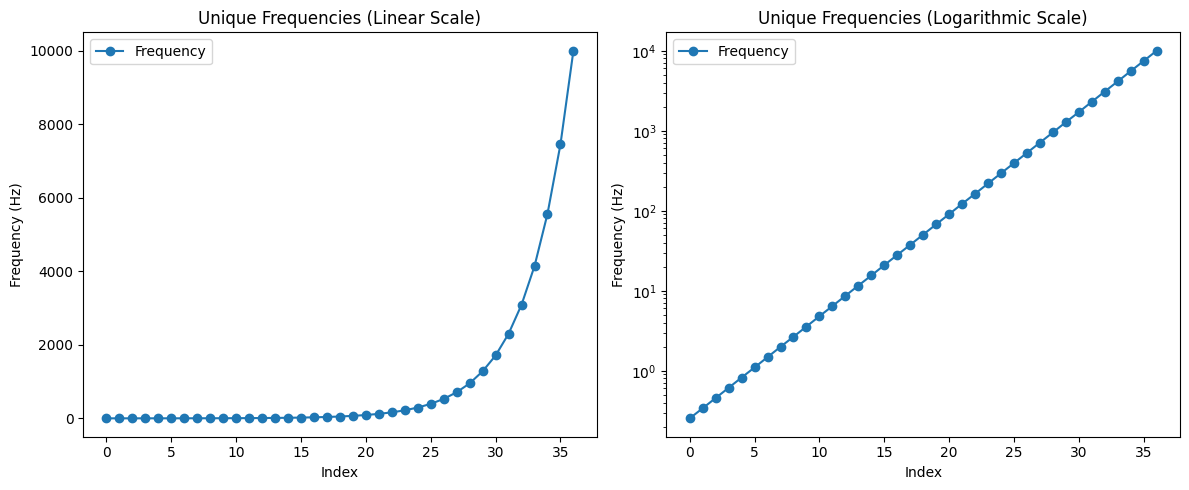

In [ ]:
freqs = [0.254, 0.34, 0.456, 0.612, 0.822, 1.1, 1.48, 1.99, 
         2.66, 3.57, 4.8, 6.43, 8.64, 11.6, 15.5, 20.9, 
         28.0, 37.5, 50.3, 67.6, 90.6, 122.0, 163.0, 
         219.0, 294.0, 394.0, 529.0, 710.0, 952.0, 1280.0, 1710.0, 
         2300.0, 3090.0, 4140.0, 5560.0, 7450.0, 10000.0]
plots.unique_frequencies(freqs)

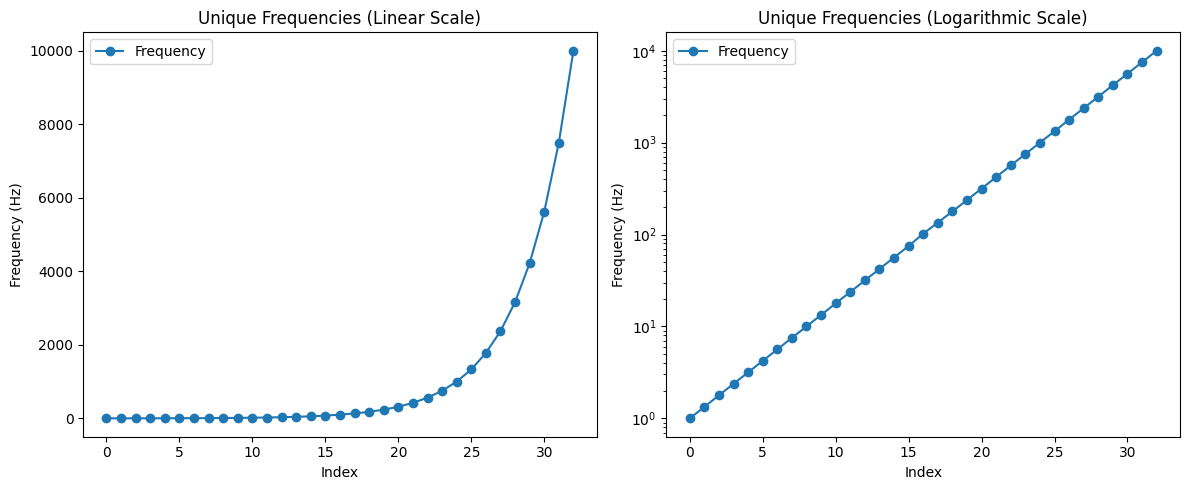

In [5]:
freqs=[0.999, 1.33, 1.78, 2.37, 3.16, 4.22, 5.62, 7.5, 
       10.0, 13.3, 17.8, 23.7, 31.6, 42.2, 56.2, 75.0, 
       102.0, 135.0, 178.0, 237.0, 316.0, 422.0, 564.0, 750.0, 
       1000.0, 1330.0, 1780.0, 2370.0, 3160.0, 4220.0, 5620.0, 7500.0, 
       10000.0]
plots.unique_frequencies(freqs)
